#**Aula 1 - Tratando os Dados**

In [1]:
import pandas as pd

In [2]:
cadastrados = pd.read_csv('https://github.com/alura-tech/alura-tech-pos-data-science-credit-scoring-streamlit/blob/main/dados/clientes_cadastrados.csv?raw=True')

In [4]:
cadastrados.head()

,ID_Cliente,Genero,Tem_carro,Tem_casa_propria,Qtd_filhos,Rendimento_anual,Categoria_de_renda,Grau_escolaridade,Estado_civil,Moradia,Idade,Anos_empregado,Tem_celular,Tem_telefone_trabalho,Tem_telefone_fixo,Tem_email,Ocupacao,Tamanho_familia
0,5008804,M,Y,Y,0,427500.0,Empregado,Ensino superior,União-estável,Apartamento alugado,-12005,-4542,1,1,0,0,NaN,2.0
1,5008805,M,Y,Y,0,427500.0,Empregado,Ensino superior,União-estável,Apartamento alugado,-12005,-4542,1,1,0,0,NaN,2.0
2,5008806,M,Y,Y,0,112500.0,Empregado,Ensino médio,Casado,Casa/apartamento próprio,-21474,-1134,1,0,0,0,Segurança,2.0
3,5008808,F,N,Y,0,270000.0,Associado comercial,Ensino médio,Solteiro,Casa/apartamento próprio,-19110,-3051,1,0,1,1,Vendas,1.0
4,5008809,F,N,Y,0,270000.0,Associado comercial,Ensino médio,Solteiro,Casa/apartamento próprio,-19110,-3051,1,0,1,1,Vendas,1.0


In [5]:
cadastrados.shape

(438557, 18)

In [ ]:
cadastrados['ID_Cliente'].value_counts() #para validar s etem valores duplicados

ID_Cliente
7702516    2
7602432    2
7836971    2
7213374    2
7052783    2
          ..
6840104    1
6840222    1
6841878    1
6842765    1
5008808    1
Name: count, Length: 438510, dtype: int64

In [10]:
cadastrados.duplicated().sum()

np.int64(0)

In [9]:
cadastrados['ID_Cliente'].duplicated()

0         False
1         False
2         False
3         False
4         False
          ...  
438552    False
438553    False
438554    False
438555    False
438556    False
Name: ID_Cliente, Length: 438557, dtype: bool

In [ ]:
cadastrados[cadastrados['ID_Cliente'].duplicated(keep=False)].shape #para contar quantas informações estão duplicadas

(94, 18)

In [ ]:
id_repetidos = cadastrados[cadastrados['ID_Cliente'].duplicated(keep=False)]['ID_Cliente'] #identifica os repitidos

In [ ]:
df_cadastrados_limpo = cadastrados.drop(id_repetidos.index) # exclui os reptidos

In [14]:
df_cadastrados_limpo.head()

,ID_Cliente,Genero,Tem_carro,Tem_casa_propria,Qtd_filhos,Rendimento_anual,Categoria_de_renda,Grau_escolaridade,Estado_civil,Moradia,Idade,Anos_empregado,Tem_celular,Tem_telefone_trabalho,Tem_telefone_fixo,Tem_email,Ocupacao,Tamanho_familia
0,5008804,M,Y,Y,0,427500.0,Empregado,Ensino superior,União-estável,Apartamento alugado,-12005,-4542,1,1,0,0,NaN,2.0
1,5008805,M,Y,Y,0,427500.0,Empregado,Ensino superior,União-estável,Apartamento alugado,-12005,-4542,1,1,0,0,NaN,2.0
2,5008806,M,Y,Y,0,112500.0,Empregado,Ensino médio,Casado,Casa/apartamento próprio,-21474,-1134,1,0,0,0,Segurança,2.0
3,5008808,F,N,Y,0,270000.0,Associado comercial,Ensino médio,Solteiro,Casa/apartamento próprio,-19110,-3051,1,0,1,1,Vendas,1.0
4,5008809,F,N,Y,0,270000.0,Associado comercial,Ensino médio,Solteiro,Casa/apartamento próprio,-19110,-3051,1,0,1,1,Vendas,1.0


In [15]:
df_cadastrados_limpo['ID_Cliente'].value_counts()

ID_Cliente
6842885    1
5008804    1
5008805    1
5008806    1
5008808    1
          ..
5008843    1
5008844    1
5008846    1
5008847    1
5008849    1
Name: count, Length: 438463, dtype: int64

In [ ]:
df_cadastrados_limpo.isnull().sum() #somar dados nulos por coluna

ID_Cliente                    0
Genero                        0
Tem_carro                     0
Tem_casa_propria              0
Qtd_filhos                    0
Rendimento_anual              0
Categoria_de_renda            0
Grau_escolaridade             0
Estado_civil                  0
Moradia                       0
Idade                         0
Anos_empregado                0
Tem_celular                   0
Tem_telefone_trabalho         0
Tem_telefone_fixo             0
Tem_email                     0
Ocupacao                 134177
Tamanho_familia               0
dtype: int64

In [ ]:
df_cadastrados_limpo['Ocupacao'].unique() # paar ver quais opções tem na coluna

array([nan, 'Segurança', 'Vendas', 'Contabilidade', 'Construção Civil',
       'Gerência', 'Motorista', 'Equipe principal', 'Alta tecnologia',
       'Limpeza', 'Serviço privado', 'Cozinha', 'Baixa qualificação',
       'Medicina', 'Secretariado', 'Garçom', 'RH', 'Corretor imobiliário',
       'TI'], dtype=object)

In [ ]:
df_cadastrados_limpo['Ocupacao'].fillna(value='Outro', inplace=True) # substituir todos os dados nulos por "outros"

C:\Users\laiss\AppData\Local\Temp\ipykernel_29504\180975226.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_cadastrados_limpo['Ocupacao'].fillna(value='Outro', inplace=True)


In [ ]:
df_cadastrados_limpo.isnull().sum() # para validar novamente a quantidade de dados nulos

ID_Cliente               0
Genero                   0
Tem_carro                0
Tem_casa_propria         0
Qtd_filhos               0
Rendimento_anual         0
Categoria_de_renda       0
Grau_escolaridade        0
Estado_civil             0
Moradia                  0
Idade                    0
Anos_empregado           0
Tem_celular              0
Tem_telefone_trabalho    0
Tem_telefone_fixo        0
Tem_email                0
Ocupacao                 0
Tamanho_familia          0
dtype: int64

In [ ]:
df_cadastrados_limpo.nunique() # numero de valores em cada coluna

ID_Cliente               438463
Genero                        2
Tem_carro                     2
Tem_casa_propria              2
Qtd_filhos                   12
Rendimento_anual            866
Categoria_de_renda            5
Grau_escolaridade             5
Estado_civil                  5
Moradia                       6
Idade                     16379
Anos_empregado             9406
Tem_celular                   1
Tem_telefone_trabalho         2
Tem_telefone_fixo             2
Tem_email                     2
Ocupacao                     19
Tamanho_familia              13
dtype: int64

In [101]:
df_cadastrados_limpo.drop('Genero', axis=1, inplace=True) #excluir colunas que não trazem retorno na analise

KeyError: "['Genero'] not found in axis"

In [25]:
df_cadastrados_limpo.drop('Tem_celular', axis=1, inplace=True)

In [ ]:
df_cadastrados_limpo['Tem_carro'].unique() # ver valores unicos da coluna

array(['Y', 'N'], dtype=object)

In [ ]:
df_cadastrados_limpo['Tem_casa_propria'].unique() # ver valores unicos da coluna

array(['Y', 'N'], dtype=object)

In [26]:
df_cadastrados_limpo['Tem_telefone_trabalho'].unique() # ver valores unicos da coluna

array([1, 0])

In [27]:
df_cadastrados_limpo['Tem_telefone_fixo'].unique()

array([0, 1])

In [28]:
df_cadastrados_limpo['Tem_email'].unique()

array([0, 1])

In [ ]:
df_cadastrados_limpo['Tem_carro'] = df_cadastrados_limpo['Tem_carro'].replace(['Y','N'],[1,0]# substituir dados
df_cadastrados_limpo['Tem_casa_propria'] = df_cadastrados_limpo['Tem_casa_propria'].replace(['Y','N'],[1,0]) # substituir dados

C:\Users\laiss\AppData\Local\Temp\ipykernel_29504\2259432855.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_cadastrados_limpo['Tem_carro'] = df_cadastrados_limpo['Tem_carro'].replace(['Y','N'],[1,0])
C:\Users\laiss\AppData\Local\Temp\ipykernel_29504\2259432855.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_cadastrados_limpo['Tem_casa_propria'] = df_cadastrados_limpo['Tem_casa_propria'].replace(['Y','N'],[1,0])


In [32]:
df_cadastrados_limpo.info()

<class 'pandas.core.frame.DataFrame'>
Index: 438463 entries, 0 to 438556
Data columns (total 16 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   ID_Cliente             438463 non-null  int64  
 1   Tem_carro              438463 non-null  int64  
 2   Tem_casa_propria       438463 non-null  int64  
 3   Qtd_filhos             438463 non-null  int64  
 4   Rendimento_anual       438463 non-null  float64
 5   Categoria_de_renda     438463 non-null  object 
 6   Grau_escolaridade      438463 non-null  object 
 7   Estado_civil           438463 non-null  object 
 8   Moradia                438463 non-null  object 
 9   Idade                  438463 non-null  int64  
 10  Anos_empregado         438463 non-null  int64  
 11  Tem_telefone_trabalho  438463 non-null  int64  
 12  Tem_telefone_fixo      438463 non-null  int64  
 13  Tem_email              438463 non-null  int64  
 14  Ocupacao               438463 non-null  o

In [ ]:
df_cadastrados_limpo.head()

,ID_Cliente,Tem_carro,Tem_casa_propria,Qtd_filhos,Rendimento_anual,Categoria_de_renda,Grau_escolaridade,Estado_civil,Moradia,Idade,Anos_empregado,Tem_telefone_trabalho,Tem_telefone_fixo,Tem_email,Ocupacao,Tamanho_familia
0,5008804,1,1,0,427500.0,Empregado,Ensino superior,União-estável,Apartamento alugado,-12005,-4542,1,0,0,Outro,2.0
1,5008805,1,1,0,427500.0,Empregado,Ensino superior,União-estável,Apartamento alugado,-12005,-4542,1,0,0,Outro,2.0
2,5008806,1,1,0,112500.0,Empregado,Ensino médio,Casado,Casa/apartamento próprio,-21474,-1134,0,0,0,Segurança,2.0
3,5008808,0,1,0,270000.0,Associado comercial,Ensino médio,Solteiro,Casa/apartamento próprio,-19110,-3051,0,1,1,Vendas,1.0
4,5008809,0,1,0,270000.0,Associado comercial,Ensino médio,Solteiro,Casa/apartamento próprio,-19110,-3051,0,1,1,Vendas,1.0


In [34]:
# Tratamento da feature Idade
df_cadastrados_limpo['Idade']=-df_cadastrados_limpo['Idade']/365.2425

In [35]:
df_cadastrados_limpo['Anos_empregado'].value_counts()

Anos_empregado
 365243    75314
-218         262
-1678        251
-249         241
-978         240
           ...  
-12233         1
-9687          1
-5492          1
-9065          1
-5924          1
Name: count, Length: 9406, dtype: int64

In [37]:
# Tratamento da feature anos empregado
df_cadastrados_limpo['Anos_empregado']=-df_cadastrados_limpo['Anos_empregado']/365.2425

In [38]:
df_cadastrados_limpo['Anos_empregado'].value_counts()

Anos_empregado
 2.737911    75314
-0.001634      262
-0.012579      251
-0.001867      241
-0.007331      240
             ...  
-0.091700        1
-0.072615        1
-0.041169        1
-0.067952        1
-0.044407        1
Name: count, Length: 9406, dtype: int64

In [49]:
df_cadastrados_limpo.loc[df_cadastrados_limpo['Anos_empregado']<0,'Anos_empregado']=0

In [50]:
df_cadastrados_limpo['Anos_empregado'].value_counts()

Anos_empregado
0.000000    363149
2.737911     75314
Name: count, dtype: int64

In [51]:
df_cadastrados_limpo.head()

,ID_Cliente,Tem_carro,Tem_casa_propria,Qtd_filhos,Rendimento_anual,Categoria_de_renda,Grau_escolaridade,Estado_civil,Moradia,Idade,Anos_empregado,Tem_telefone_trabalho,Tem_telefone_fixo,Tem_email,Ocupacao,Tamanho_familia
0,5008804,1,1,0,427500.0,Empregado,Ensino superior,União-estável,Apartamento alugado,-0.089991,0.0,1,0,0,Outro,2.0
1,5008805,1,1,0,427500.0,Empregado,Ensino superior,União-estável,Apartamento alugado,-0.089991,0.0,1,0,0,Outro,2.0
2,5008806,1,1,0,112500.0,Empregado,Ensino médio,Casado,Casa/apartamento próprio,-0.160972,0.0,0,0,0,Segurança,2.0
3,5008808,0,1,0,270000.0,Associado comercial,Ensino médio,Solteiro,Casa/apartamento próprio,-0.143251,0.0,0,1,1,Vendas,1.0
4,5008809,0,1,0,270000.0,Associado comercial,Ensino médio,Solteiro,Casa/apartamento próprio,-0.143251,0.0,0,1,1,Vendas,1.0


In [58]:
pip install matplotlib

   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   ----------- ---------------------------- 2.4/8.1 MB 12.2 MB/s eta 0:00:01
   --------------------------------- ------ 6.8/8.1 MB 17.5 MB/s eta 0:00:01
   ---------------------------------------- 8.1/8.1 MB 16.2 MB/s  0:00:00
   ---------------------------------------- 0.0/2.3 MB ? eta -:--:--
   ---------------------------------------- 2.3/2.3 MB 25.7 MB/s  0:00:00
   ---------------------------------------- 0.0/7.0 MB ? eta -:--:--
   -------------------------------- ------- 5.8/7.0 MB 27.1 MB/s eta 0:00:01
   ---------------------------------------- 7.0/7.0 MB 25.4 MB/s  0:00:00

   ---------------------------------------- 0/6 [pillow]
   ---------------------------------------- 0/6 [pillow]
   ---------------------------------------- 0/6 [pillow]
   ---------------------------------------- 0/6 [pillow]
   ---------------------------------------- 0/6 [pillow]
   ---------------------------------------- 0/6 [pillo


[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [62]:
pip install seaborn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [63]:
import matplotlib.pyplot as plt
import seaborn as sns

<Axes: >

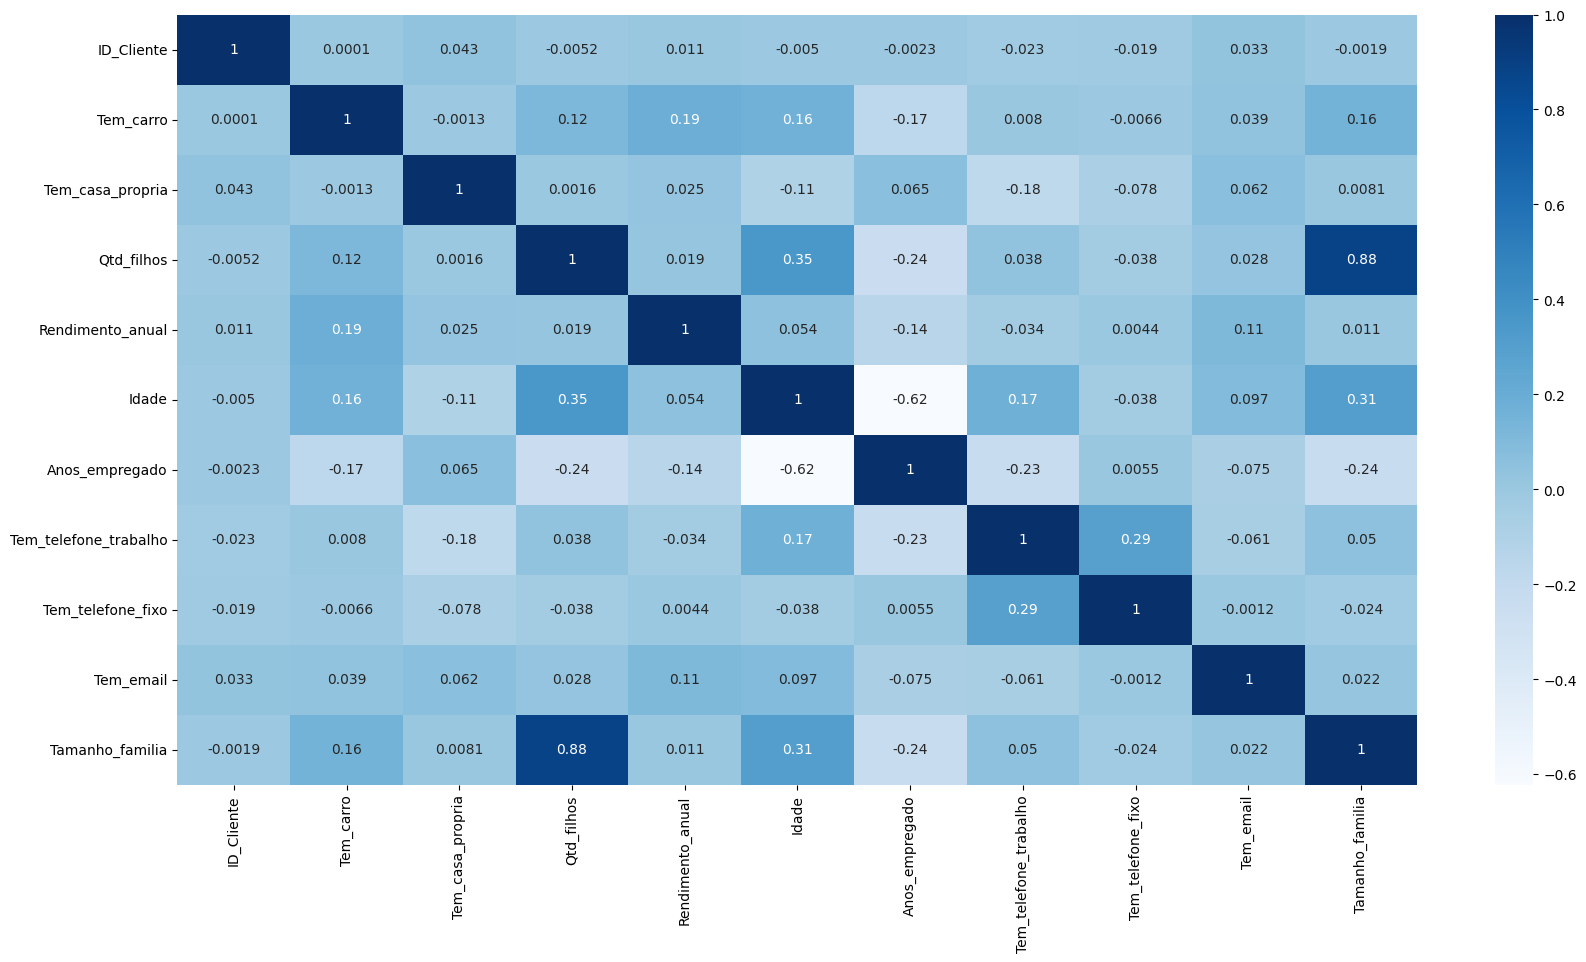

In [68]:
# 1. Calcular a matriz de correlação.
# O parâmetro 'numeric_only=True' garante que apenas as colunas com tipos de dados
# numéricos (int, float) serão consideradas, ignorando as colunas de texto (como a que tem 'Empregado').
corr = df_cadastrados_limpo.corr(numeric_only=True)

# 2. Configurar o tamanho da figura
plt.figure(figsize = (20,10))

# 3. Gerar o mapa de calor com a matriz de correlação numérica
sns.heatmap(corr, cmap="Blues", annot=True)

# O código deve rodar agora, pois eliminamos as strings do cálculo.

<Axes: >

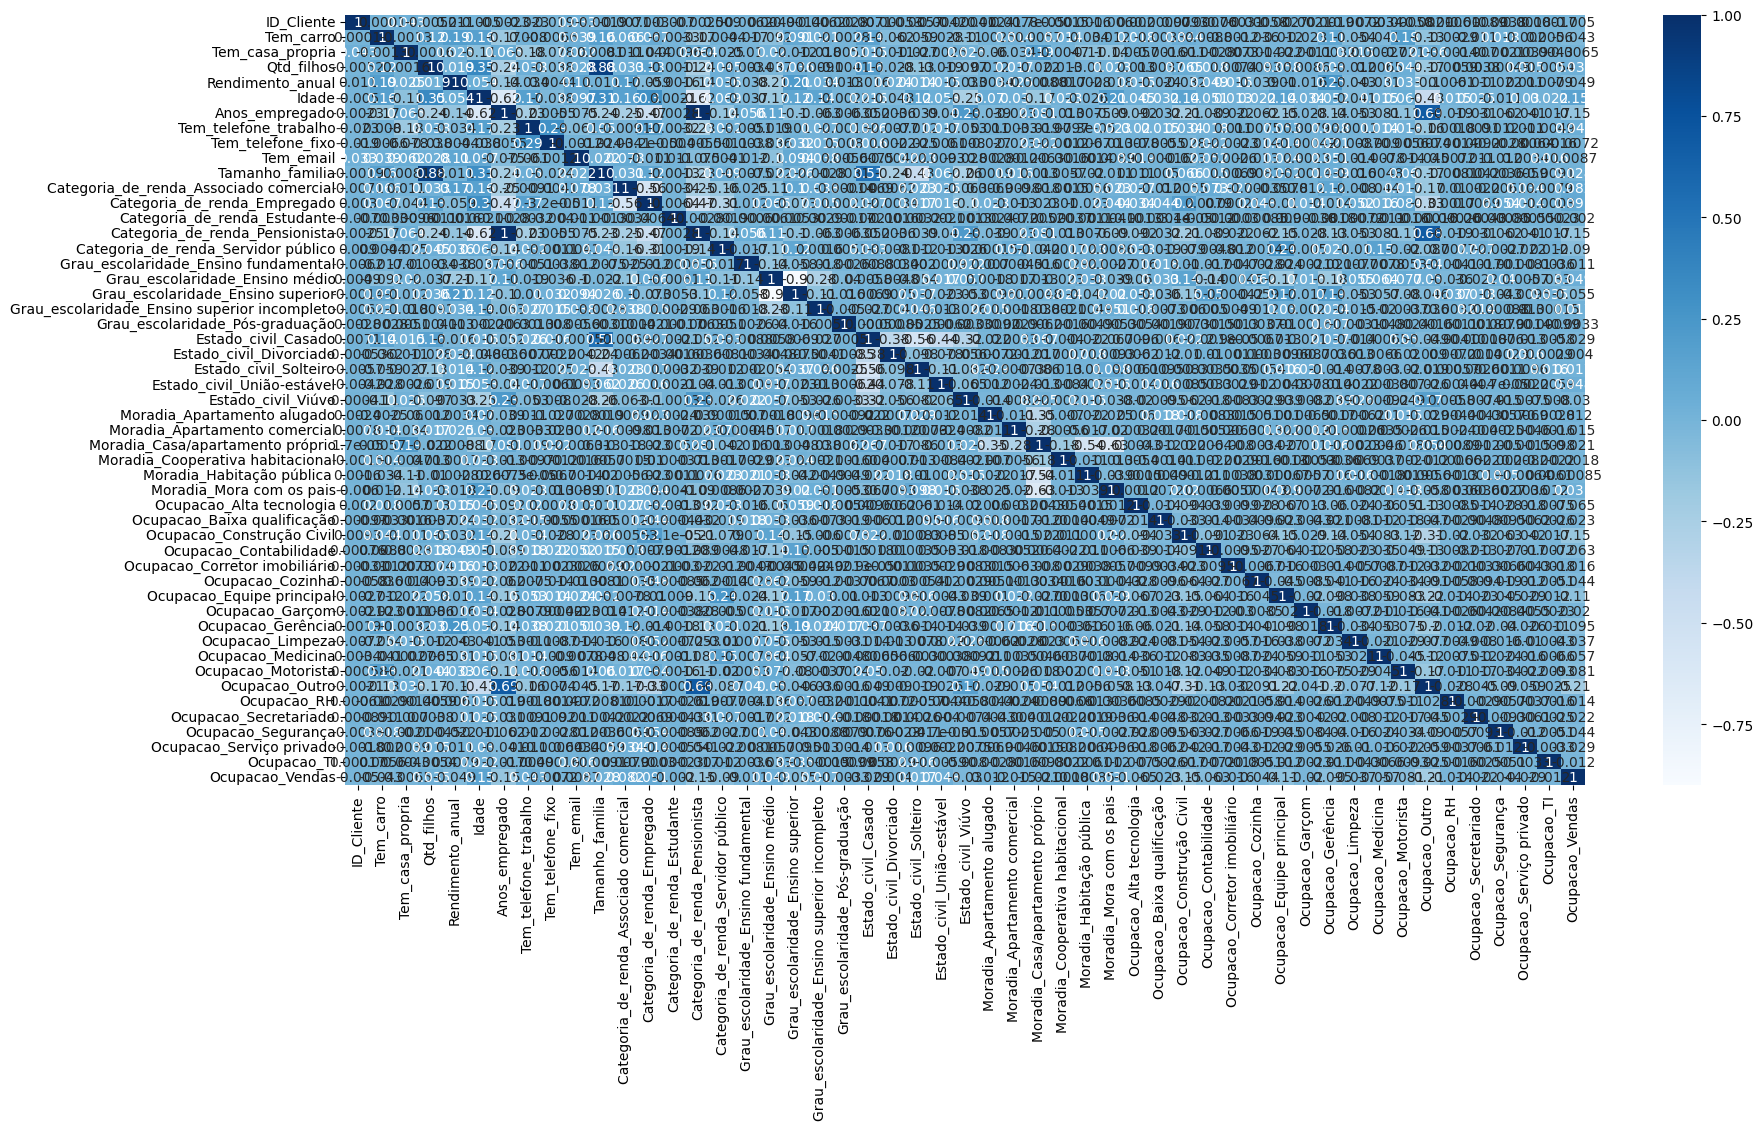

In [73]:
# Create a new DataFrame with one-hot encoded columns for all object/category types
df_encoded = pd.get_dummies(df_cadastrados_limpo)

# Now calculate the correlation on the fully numeric DataFrame
corr = df_encoded.corr()
plt.figure(figsize = (20,10))
sns.heatmap(corr, cmap="Blues", annot=True)

In [75]:
df_cadastrados_limpo.drop(['Qtd_filhos'], axis=1, inplace=True)

In [76]:
df_cadastrados_limpo=df_cadastrados_limpo[['ID_Cliente', 'Tem_carro', 'Tem_casa_propria', 
                                           'Tem_telefone_trabalho', 'Tem_telefone_fixo', 'Tem_email',
                                           'Tamanho_familia', 'Rendimento_anual', 'Idade', 'Anos_empregado',
                                           'Categoria_de_renda', 'Grau_escolaridade', 'Estado_civil',
                                           'Moradia', 'Ocupacao']]

In [77]:
df_cadastrados_limpo.head()

,ID_Cliente,Tem_carro,Tem_casa_propria,Tem_telefone_trabalho,Tem_telefone_fixo,Tem_email,Tamanho_familia,Rendimento_anual,Idade,Anos_empregado,Categoria_de_renda,Grau_escolaridade,Estado_civil,Moradia,Ocupacao
0,5008804,1,1,1,0,0,2.0,427500.0,-0.089991,0.0,Empregado,Ensino superior,União-estável,Apartamento alugado,Outro
1,5008805,1,1,1,0,0,2.0,427500.0,-0.089991,0.0,Empregado,Ensino superior,União-estável,Apartamento alugado,Outro
2,5008806,1,1,0,0,0,2.0,112500.0,-0.160972,0.0,Empregado,Ensino médio,Casado,Casa/apartamento próprio,Segurança
3,5008808,0,1,0,1,1,1.0,270000.0,-0.143251,0.0,Associado comercial,Ensino médio,Solteiro,Casa/apartamento próprio,Vendas
4,5008809,0,1,0,1,1,1.0,270000.0,-0.143251,0.0,Associado comercial,Ensino médio,Solteiro,Casa/apartamento próprio,Vendas


In [78]:
colunas_quantitativas = ['Tamanho_familia', 'Rendimento_anual', 'Idade', 'Anos_empregado']

In [79]:
df_cadastrados_limpo[colunas_quantitativas].describe()

,Tamanho_familia,Rendimento_anual,Idade,Anos_empregado
count,438463.000000,4.384630e+05,438463.000000,438463.000000
mean,2.194461,1.875220e+05,-0.119923,0.470286
std,0.897194,1.100832e+05,0.031372,1.032683
min,1.000000,2.610000e+04,-0.188910,0.000000
25%,2.000000,1.215000e+05,-0.146055,0.000000
50%,2.000000,1.611000e+05,-0.117165,0.000000
75%,3.000000,2.250000e+05,-0.093807,0.000000
max,20.000000,6.750000e+06,-0.056139,2.737911


In [ ]:
df_cadastrados_limpo['Categoria_de_renda'].value_counts(normalize = True) * 100 #transformando uma informação em porcentagem

Categoria_de_renda
Empregado              51.557144
Associado comercial    22.972520
Pensionista            17.214223
Servidor público        8.252236
Estudante               0.003877
Name: proportion, dtype: float64

In [81]:
df_cadastrados_limpo['Grau_escolaridade'].value_counts(normalize = True) * 100

Grau_escolaridade
Ensino médio                  68.821314
Ensino superior               26.797928
Ensino superior incompleto     3.385690
Ensino fundamental             0.923909
Pós-graduação                  0.071158
Name: proportion, dtype: float64

In [82]:
df_cadastrados_limpo['Estado_civil'].value_counts(normalize = True) * 100

Estado_civil
Casado           68.367912
Solteiro         12.601976
União-estável     8.329323
Divorciado        6.214663
Viúvo             4.486125
Name: proportion, dtype: float64

In [83]:
df_cadastrados_limpo['Moradia'].value_counts(normalize = True) * 100

Moradia
Casa/apartamento próprio    89.801876
Mora com os pais             4.349740
Habitação pública            3.241094
Apartamento alugado          1.362259
Apartamento comercial        0.894032
Cooperativa habitacional     0.350999
Name: proportion, dtype: float64

In [84]:
df_cadastrados_limpo['Ocupacao'].value_counts(normalize = True) * 100

Ocupacao
Outro                   30.601670
Construção Civil        17.840730
Equipe principal         9.805388
Vendas                   9.371828
Gerência                 8.091219
Motorista                5.949191
Alta tecnologia          3.941724
Contabilidade            3.644549
Medicina                 3.083042
Cozinha                  1.841432
Segurança                1.822959
Limpeza                  1.332610
Serviço privado          0.787980
Baixa qualificação       0.488069
Secretariado             0.466174
Garçom                   0.379736
Corretor imobiliário     0.237420
RH                       0.176526
TI                       0.137754
Name: proportion, dtype: float64

In [85]:
import matplotlib as mpl

In [86]:
#Configurações dos gráficos:
mpl.rcParams['font.size'] = 14
mpl.rcParams['figure.figsize'] = (10,6)

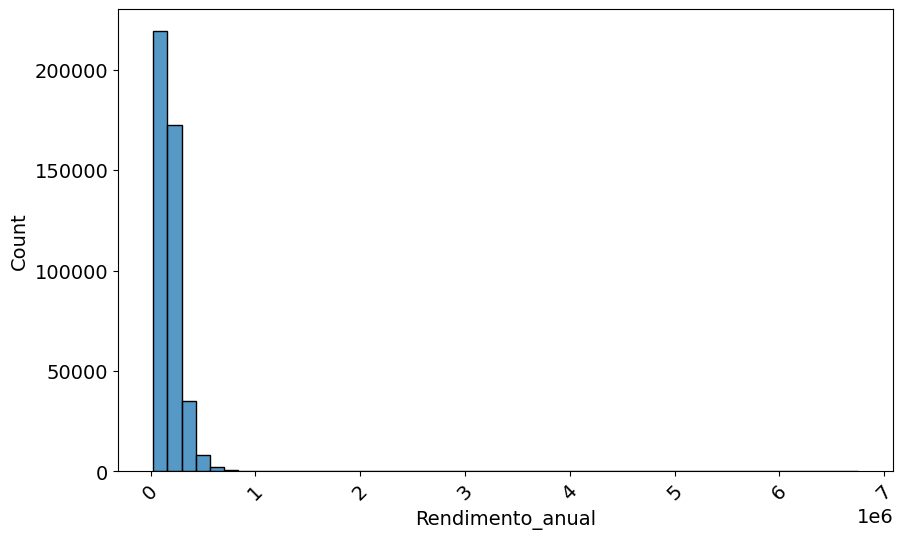

In [87]:
sns.histplot(data=df_cadastrados_limpo, x='Rendimento_anual', bins=50) 
plt.xticks(rotation=45)
plt.show()

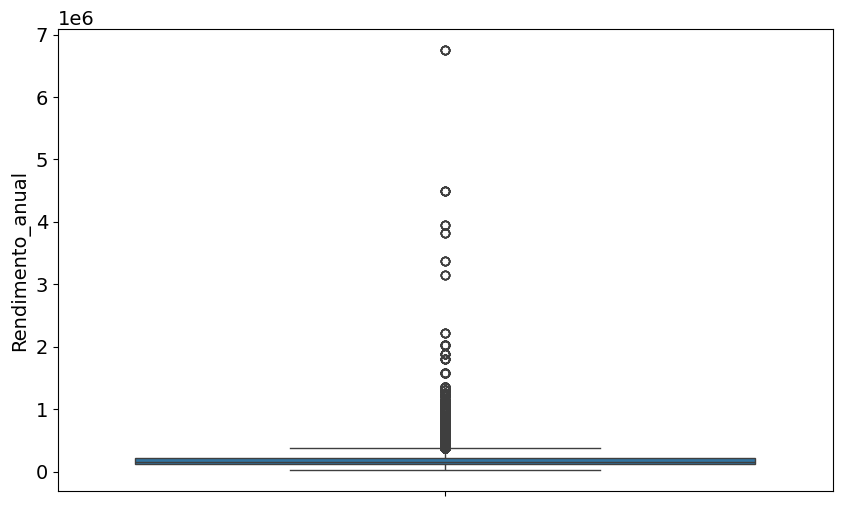

In [88]:
sns.boxplot(data=df_cadastrados_limpo, y='Rendimento_anual') 
plt.xticks(rotation=45)
plt.show()

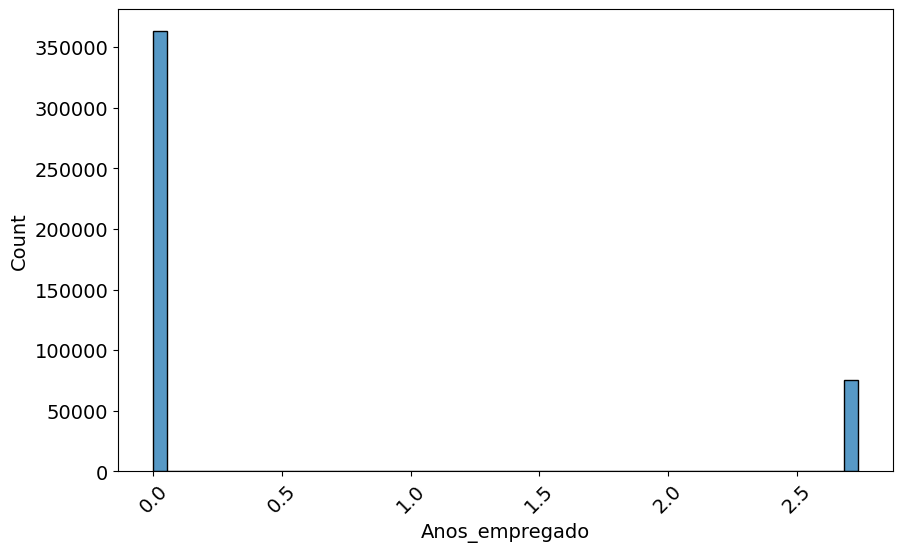

In [89]:
sns.histplot(data=df_cadastrados_limpo, x='Anos_empregado', bins=50) 
plt.xticks(rotation=45)
plt.show()

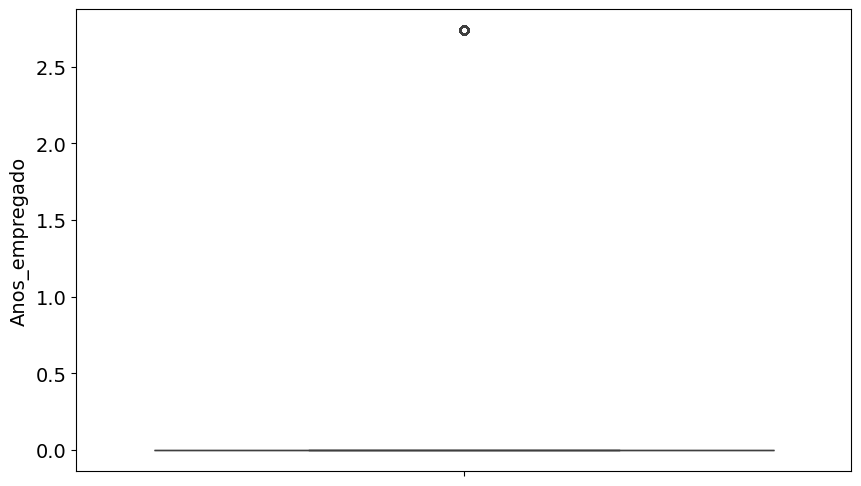

In [91]:
sns.boxplot(data=df_cadastrados_limpo, y='Anos_empregado') 
plt.xticks(rotation=45)
plt.show()

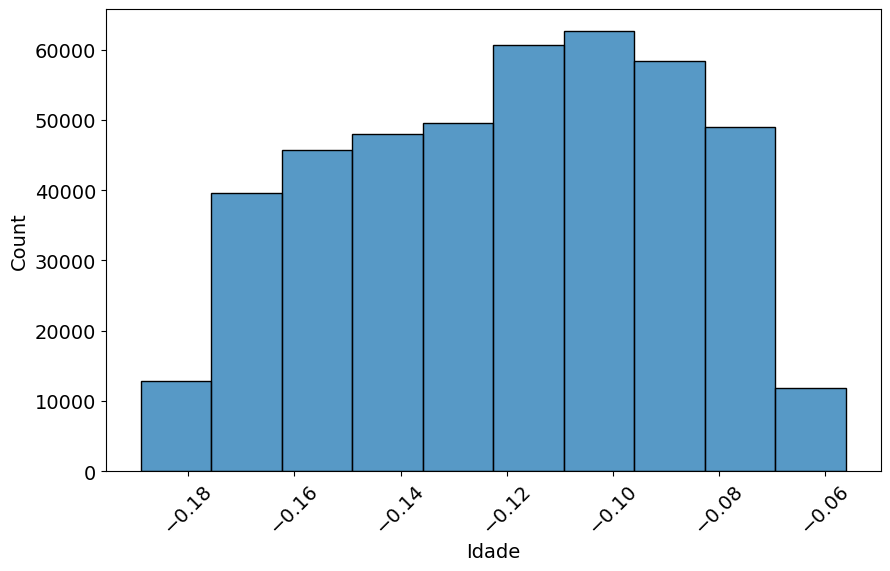

In [92]:
sns.histplot(data=df_cadastrados_limpo, x='Idade', bins=10) 
plt.xticks(rotation=45)
plt.show()

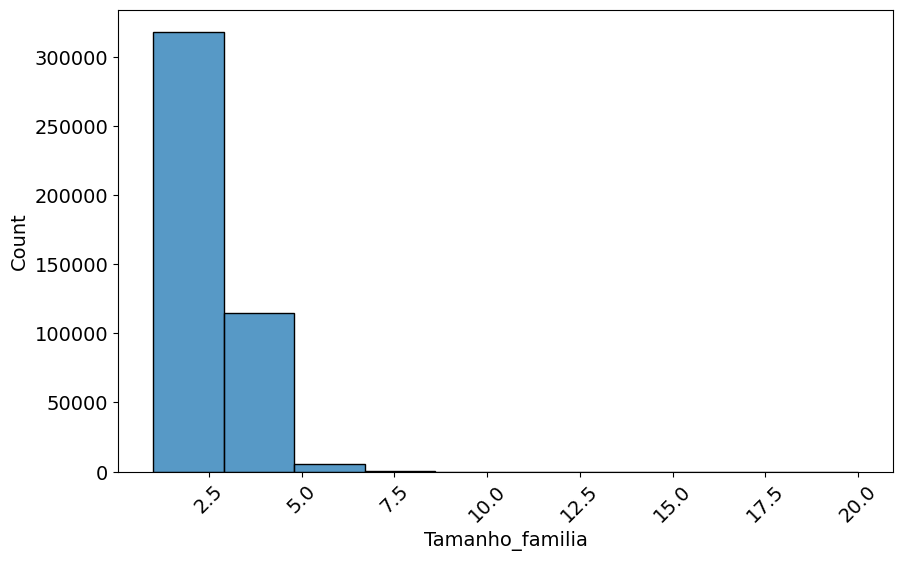

In [93]:
sns.histplot(data=df_cadastrados_limpo, x='Tamanho_familia', bins=10) 
plt.xticks(rotation=45)
plt.show()

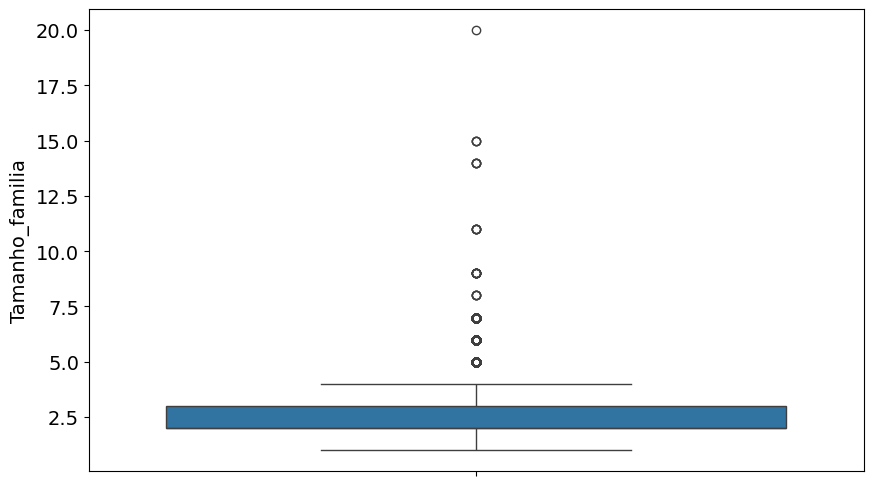

In [94]:
sns.boxplot(data=df_cadastrados_limpo, y='Tamanho_familia') 
plt.xticks(rotation=45)
plt.show()

In [95]:
'''Técnica para remoção de outliers a partir de um intervalo de confiança
o valor +- o desvio-padrão'''

coluna = df_cadastrados_limpo['Rendimento_anual']

coluna_med = coluna.mean()
coluna_std = coluna.std()

limite_sup = coluna_med + (2 * coluna_std)
limite_inf = coluna_med - (2 * coluna_std)

index_outliers = []

for index, valor in coluna.items(): 
  if valor > limite_sup or valor < limite_inf:
    index_outliers.append(index)

len(index_outliers)

12641

In [96]:
df_clientes_cadastrados_sem_outliers = df_cadastrados_limpo.drop(index_outliers)
df_clientes_cadastrados_sem_outliers.shape

(425822, 15)

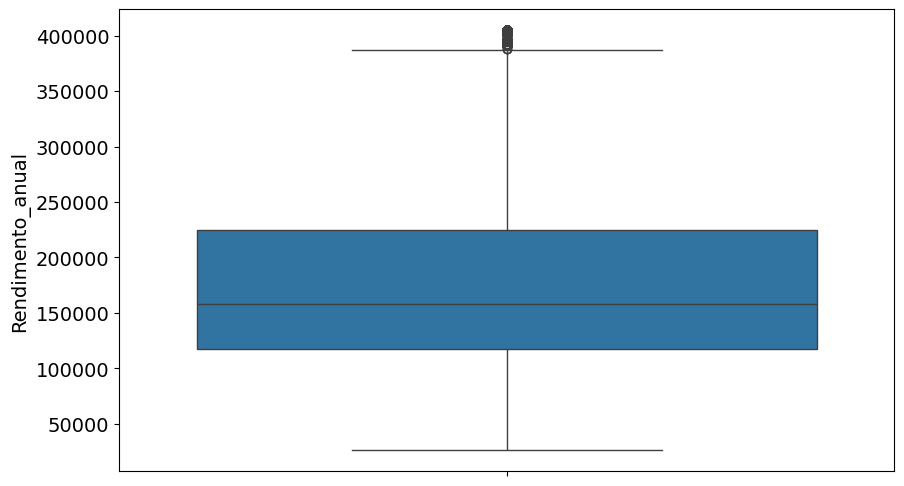

In [97]:
sns.boxplot(data=df_clientes_cadastrados_sem_outliers, y='Rendimento_anual') 
plt.xticks(rotation=45)
plt.show()

In [98]:
df_clientes_cadastrados_sem_outliers['Rendimento_anual'].max

<bound method Series.max of 2         112500.0
3         270000.0
4         270000.0
5         270000.0
6         270000.0
            ...   
438552    135000.0
438553    103500.0
438554     54000.0
438555     72000.0
438556    121500.0
Name: Rendimento_anual, Length: 425822, dtype: float64>

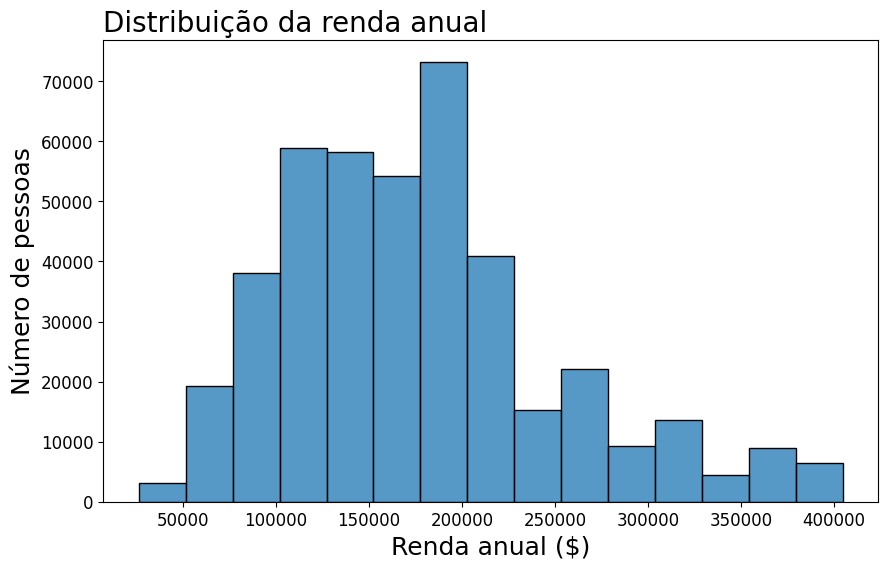

In [99]:
fig = plt.figure(figsize=(10,6))
ax = sns.histplot(data=df_clientes_cadastrados_sem_outliers, x='Rendimento_anual', bins=15)
plt.xticks(rotation=360)
ax.set_title('Distribuição da renda anual', fontsize = 20, loc='left')
ax.set_ylabel('Número de pessoas', fontsize = 18)
ax.set_xlabel('Renda anual ($)', fontsize = 18)
ax.yaxis.set_tick_params(labelsize=12)
ax.xaxis.set_tick_params(labelsize=12)
plt.show()

In [100]:
df_clientes_cadastrados_tratamento1 = df_clientes_cadastrados_sem_outliers
df_clientes_cadastrados_tratamento1.shape

(425822, 15)